In [83]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
nudratabbas_healthcare_fraud_detection_dataset_path = kagglehub.dataset_download('nudratabbas/healthcare-fraud-detection-dataset')

print('Data source import complete.')


Using Colab cache for faster access to the 'healthcare-fraud-detection-dataset' dataset.
Data source import complete.


In [84]:
import pandas as pd

df = pd.read_csv('/kaggle/input/healthcare-fraud-detection-dataset/healthcare_fraud_detection.csv')
df.head()


,Provider_ID,Claim_ID,Patient_Age,Patient_Gender,Diagnosis_Code,Procedure_Code,Claim_Amount,Approved_Amount,Insurance_Type,Claim_Submission_Date,Days_Between_Service_and_Claim,Number_of_Claims_Per_Provider_Monthly,Provider_Specialty,Patient_State,Claim_Status,Is_Fraud,Length_of_Stay,Visit_Type,Chronic_Condition_Flag,Prior_Visits_12m
0,P0052,C0000000,37,Male,I25.10,36415,443.51,393.16,Medicaid,2024-09-01,13,70,Cardiology,NY,Approved,0,0,Outpatient,1,2.0
1,P0121,C0000001,21,Female,E11.9,99213,467.50,461.33,Self-Pay,2022-09-05,5,62,General Practice,IL,Pending,0,5,Inpatient,1,2.0
2,P0140,C0000002,78,Female,J06.9,93000,591.69,530.06,Medicaid,2022-04-11,29,60,Cardiology,IL,Pending,0,5,Inpatient,1,3.0
3,P0202,C0000003,65,Male,I10,93000,235.15,189.11,Private,2023-10-11,22,70,General Practice,TX,Approved,0,0,Emergency,0,5.0
4,P0135,C0000004,36,Male,M54.5,85025,487.96,369.91,Private,2023-09-05,21,67,Pulmonology,PA,Approved,0,5,Inpatient,0,4.0


In [85]:
# !pip install ydata_profiling
# from ydata_profiling import ProfileReport
# profile = ProfileReport(df, title="Pandas Profiling Report")
# profile.to_file("your_report.html")
# profile.to_notebook_iframe()

In [86]:
df.head()

,Provider_ID,Claim_ID,Patient_Age,Patient_Gender,Diagnosis_Code,Procedure_Code,Claim_Amount,Approved_Amount,Insurance_Type,Claim_Submission_Date,Days_Between_Service_and_Claim,Number_of_Claims_Per_Provider_Monthly,Provider_Specialty,Patient_State,Claim_Status,Is_Fraud,Length_of_Stay,Visit_Type,Chronic_Condition_Flag,Prior_Visits_12m
0,P0052,C0000000,37,Male,I25.10,36415,443.51,393.16,Medicaid,2024-09-01,13,70,Cardiology,NY,Approved,0,0,Outpatient,1,2.0
1,P0121,C0000001,21,Female,E11.9,99213,467.50,461.33,Self-Pay,2022-09-05,5,62,General Practice,IL,Pending,0,5,Inpatient,1,2.0
2,P0140,C0000002,78,Female,J06.9,93000,591.69,530.06,Medicaid,2022-04-11,29,60,Cardiology,IL,Pending,0,5,Inpatient,1,3.0
3,P0202,C0000003,65,Male,I10,93000,235.15,189.11,Private,2023-10-11,22,70,General Practice,TX,Approved,0,0,Emergency,0,5.0
4,P0135,C0000004,36,Male,M54.5,85025,487.96,369.91,Private,2023-09-05,21,67,Pulmonology,PA,Approved,0,5,Inpatient,0,4.0


In [87]:
print(df.isna().mean().sort_values(ascending=0) * 100)
print('')
print(df.isna().sum().sort_values(ascending=0))

Provider_Specialty                       3.5
Prior_Visits_12m                         3.5
Insurance_Type                           3.5
Provider_ID                              0.0
Patient_Gender                           0.0
Patient_Age                              0.0
Claim_ID                                 0.0
Diagnosis_Code                           0.0
Approved_Amount                          0.0
Claim_Submission_Date                    0.0
Claim_Amount                             0.0
Procedure_Code                           0.0
Number_of_Claims_Per_Provider_Monthly    0.0
Days_Between_Service_and_Claim           0.0
Claim_Status                             0.0
Patient_State                            0.0
Is_Fraud                                 0.0
Length_of_Stay                           0.0
Visit_Type                               0.0
Chronic_Condition_Flag                   0.0
dtype: float64

Provider_Specialty                       350
Prior_Visits_12m                       

In [88]:
print(df.shape)
print(df.duplicated().sum())

(10000, 20)
0


In [89]:
## Cleaning

df.select_dtypes(include='object')

,Provider_ID,Claim_ID,Patient_Gender,Diagnosis_Code,Insurance_Type,Claim_Submission_Date,Provider_Specialty,Patient_State,Claim_Status,Visit_Type
0,P0052,C0000000,Male,I25.10,Medicaid,2024-09-01,Cardiology,NY,Approved,Outpatient
1,P0121,C0000001,Female,E11.9,Self-Pay,2022-09-05,General Practice,IL,Pending,Inpatient
2,P0140,C0000002,Female,J06.9,Medicaid,2022-04-11,Cardiology,IL,Pending,Inpatient
3,P0202,C0000003,Male,I10,Private,2023-10-11,General Practice,TX,Approved,Emergency
4,P0135,C0000004,Male,M54.5,Private,2023-09-05,Pulmonology,PA,Approved,Inpatient
...,...,...,...,...,...,...,...,...,...,...
9995,P0289,C0009995,Male,E78.5,Private,2024-09-24,Internal Medicine,PA,Approved,Inpatient
9996,P0248,C0009996,Male,K21.9,Self-Pay,2023-01-04,Orthopedics,IL,Approved,Inpatient
9997,P0122,C0009997,Female,F41.9,Medicare,2024-06-30,Neurology,OH,Rejected,Emergency
9998,P0072,C0009998,Female,I10,Medicare,2022-03-15,Cardiology,TX,Pending,Emergency


In [90]:
## Data cleaning

for col in df.select_dtypes(include='object'):
  df[col] = df[col].str.lower().str.strip()
print(df.shape)

(10000, 20)


In [91]:
# import seaborn as sns
# sns.heatmap(df.isnull(), cbar=False)

In [92]:
df.head()

,Provider_ID,Claim_ID,Patient_Age,Patient_Gender,Diagnosis_Code,Procedure_Code,Claim_Amount,Approved_Amount,Insurance_Type,Claim_Submission_Date,Days_Between_Service_and_Claim,Number_of_Claims_Per_Provider_Monthly,Provider_Specialty,Patient_State,Claim_Status,Is_Fraud,Length_of_Stay,Visit_Type,Chronic_Condition_Flag,Prior_Visits_12m
0,p0052,c0000000,37,male,i25.10,36415,443.51,393.16,medicaid,2024-09-01,13,70,cardiology,ny,approved,0,0,outpatient,1,2.0
1,p0121,c0000001,21,female,e11.9,99213,467.50,461.33,self-pay,2022-09-05,5,62,general practice,il,pending,0,5,inpatient,1,2.0
2,p0140,c0000002,78,female,j06.9,93000,591.69,530.06,medicaid,2022-04-11,29,60,cardiology,il,pending,0,5,inpatient,1,3.0
3,p0202,c0000003,65,male,i10,93000,235.15,189.11,private,2023-10-11,22,70,general practice,tx,approved,0,0,emergency,0,5.0
4,p0135,c0000004,36,male,m54.5,85025,487.96,369.91,private,2023-09-05,21,67,pulmonology,pa,approved,0,5,inpatient,0,4.0


In [93]:
df.describe(include='number')

,Patient_Age,Procedure_Code,Claim_Amount,Approved_Amount,Days_Between_Service_and_Claim,Number_of_Claims_Per_Provider_Monthly,Is_Fraud,Length_of_Stay,Chronic_Condition_Flag,Prior_Visits_12m
count,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,9650.000000
mean,49.755000,86905.21170,572.804406,475.514157,14.413800,68.628000,0.082900,2.19930,0.292000,3.026425
std,17.910144,14965.32496,406.202437,323.257165,8.489875,14.905872,0.275745,1.71046,0.454705,1.722789
min,1.000000,36415.00000,60.210000,50.350000,0.000000,42.000000,0.000000,0.00000,0.000000,0.000000
25%,37.750000,80053.00000,305.205000,257.200000,7.000000,60.000000,0.000000,1.00000,0.000000,2.000000
50%,50.000000,93000.00000,461.225000,388.370000,14.000000,66.000000,0.000000,2.00000,0.000000,3.000000
75%,62.000000,99213.00000,711.365000,598.347500,22.000000,72.000000,0.000000,3.00000,1.000000,4.000000
max,95.000000,99214.00000,6590.700000,4270.890000,29.000000,144.000000,1.000000,5.00000,1.000000,12.000000


In [94]:
## Handling missing values

df = df.drop(columns=["Claim_ID"])
df = df.drop(columns=["Provider_ID"])
df = df.drop(columns=["Claim_Submission_Date"])

df["Prior_Visits_12m"] = df["Prior_Visits_12m"].fillna(df["Prior_Visits_12m"].median())
df["Insurance_Type"] = df["Insurance_Type"].fillna(df["Insurance_Type"].mode()[0])
df["Provider_Specialty"] = df["Provider_Specialty"].fillna(df["Provider_Specialty"].mode()[0])
df['Procedure_Code'] = df['Procedure_Code'].astype(str)

In [95]:
print(df.isna().mean().sort_values(ascending=0) * 100)
print('')
print(df.isna().sum().sort_values(ascending=0))

Patient_Age                              0.0
Patient_Gender                           0.0
Diagnosis_Code                           0.0
Procedure_Code                           0.0
Claim_Amount                             0.0
Approved_Amount                          0.0
Insurance_Type                           0.0
Days_Between_Service_and_Claim           0.0
Number_of_Claims_Per_Provider_Monthly    0.0
Provider_Specialty                       0.0
Patient_State                            0.0
Claim_Status                             0.0
Is_Fraud                                 0.0
Length_of_Stay                           0.0
Visit_Type                               0.0
Chronic_Condition_Flag                   0.0
Prior_Visits_12m                         0.0
dtype: float64

Patient_Age                              0
Patient_Gender                           0
Diagnosis_Code                           0
Procedure_Code                           0
Claim_Amount                             0
Appr

In [96]:
## Handle rare category

def handle_rare(df, col, thresold=10):
  freq = df[col].value_counts()
  rare = freq[freq < thresold].index
  df[col] = df[col].replace(rare, 'others')
  return df
for col in df.select_dtypes(include='object').columns:
  df = handle_rare(df, col)

In [97]:
## Final check

print("Shape:", df.shape)

print("\nMissing:")
print(df.isnull().sum())

print("\nDuplicate:", df.duplicated().sum())

Shape: (10000, 17)

Missing:
Patient_Age                              0
Patient_Gender                           0
Diagnosis_Code                           0
Procedure_Code                           0
Claim_Amount                             0
Approved_Amount                          0
Insurance_Type                           0
Days_Between_Service_and_Claim           0
Number_of_Claims_Per_Provider_Monthly    0
Provider_Specialty                       0
Patient_State                            0
Claim_Status                             0
Is_Fraud                                 0
Length_of_Stay                           0
Visit_Type                               0
Chronic_Condition_Flag                   0
Prior_Visits_12m                         0
dtype: int64

Duplicate: 0


In [98]:
df.head()

,Patient_Age,Patient_Gender,Diagnosis_Code,Procedure_Code,Claim_Amount,Approved_Amount,Insurance_Type,Days_Between_Service_and_Claim,Number_of_Claims_Per_Provider_Monthly,Provider_Specialty,Patient_State,Claim_Status,Is_Fraud,Length_of_Stay,Visit_Type,Chronic_Condition_Flag,Prior_Visits_12m
0,37,male,i25.10,36415,443.51,393.16,medicaid,13,70,cardiology,ny,approved,0,0,outpatient,1,2.0
1,21,female,e11.9,99213,467.50,461.33,self-pay,5,62,general practice,il,pending,0,5,inpatient,1,2.0
2,78,female,j06.9,93000,591.69,530.06,medicaid,29,60,cardiology,il,pending,0,5,inpatient,1,3.0
3,65,male,i10,93000,235.15,189.11,private,22,70,general practice,tx,approved,0,0,emergency,0,5.0
4,36,male,m54.5,85025,487.96,369.91,private,21,67,pulmonology,pa,approved,0,5,inpatient,0,4.0


In [99]:
y = df['Is_Fraud']
X = df.drop('Is_Fraud', axis=1)

In [100]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [101]:
## Encoding

from sklearn.preprocessing import OneHotEncoder
import pandas as pd

categorical_cols = df.select_dtypes(include= 'object').columns.tolist()

encoder = OneHotEncoder(drop='first', sparse_output=False)

X_train_encoded = encoder.fit_transform(X_train[categorical_cols])
X_test_encoded = encoder.transform(X_test[categorical_cols])

train_encoded_df= pd.DataFrame(
    X_train_encoded,
    columns= encoder.get_feature_names_out(categorical_cols),
    index= X_train.index
)
test_encoded_df= pd.DataFrame(
    X_test_encoded,
    columns= encoder.get_feature_names_out(categorical_cols),
    index= X_test.index
)

X_train_final= pd.concat([X_train.drop(columns= categorical_cols), train_encoded_df], axis=1)
X_test_final= pd.concat([X_test.drop(columns= categorical_cols), test_encoded_df], axis=1)

In [102]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE

# Smote
smote = SMOTE(sampling_strategy= 0.3, random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_final, y_train)

print("Jumlah data SEBELUM disamakan:")
print(y_train.value_counts())
print("\nJumlah data SESUDAH disamakan (SMOTE):")
print(y_train_resampled.value_counts())
print("-" * 50)

# Model
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    class_weight='balanced',
    random_state=42
)

model.fit(X_train_resampled, y_train_resampled)

# Predict
y_pred = model.predict(X_test_final)

# Evaluasi
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\n--- MATRIX TEBAKAN (CONFUSION MATRIX) ---")

print(confusion_matrix(y_test, y_pred))

print("\n--- RAPOR DETAIL (CLASSIFICATION REPORT) ---")
print(classification_report(y_test, y_pred))

Jumlah data SEBELUM disamakan:
Is_Fraud
0    7324
1     676
Name: count, dtype: int64

Jumlah data SESUDAH disamakan (SMOTE):
Is_Fraud
0    7324
1    2197
Name: count, dtype: int64
--------------------------------------------------
Accuracy: 0.9405

--- MATRIX TEBAKAN (CONFUSION MATRIX) ---
[[1736  111]
 [   8  145]]

--- RAPOR DETAIL (CLASSIFICATION REPORT) ---
              precision    recall  f1-score   support

           0       1.00      0.94      0.97      1847
           1       0.57      0.95      0.71       153

    accuracy                           0.94      2000
   macro avg       0.78      0.94      0.84      2000
weighted avg       0.96      0.94      0.95      2000



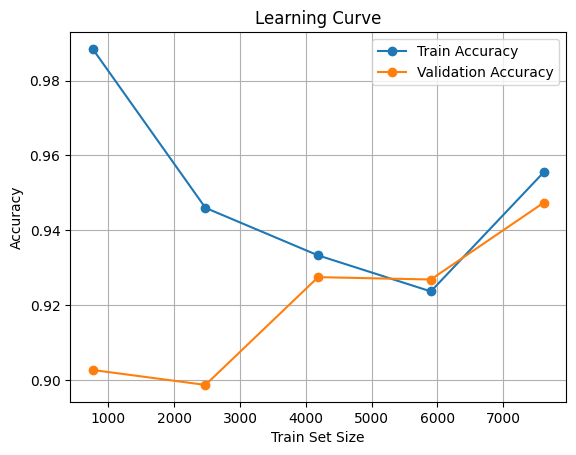

In [103]:
# learning curve
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt

train_sizes, train_scores, val_scores = learning_curve(
	model, X_train_resampled, y_train_resampled, cv=5, scoring='accuracy'
)

# Rata-rata accuracy
train_scores_mean = train_scores.mean(axis=1)
val_scores_mean = val_scores.mean(axis=1)

plt.plot(train_sizes, train_scores_mean, 'o-', label="Train Accuracy")
plt.plot(train_sizes, val_scores_mean, 'o-', label="Validation Accuracy")
plt.legend()
plt.xlabel("Train Set Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve")
plt.grid()
plt.show()